In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

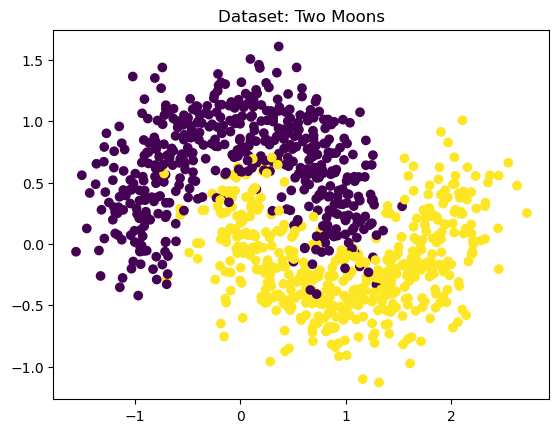

In [2]:
X, y = make_moons(n_samples=1000, noise=0.25, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Dataset: Two Moons")
plt.show()

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
models = {
    "Shallow (1 layer)": (10,),
    "Medium (2 layers)": (20, 20),
    "Deep (4 layers)": (50, 50, 50, 50)
}

trained_models = {}
results = {}

In [5]:
for name, layers in models.items():
    model = MLPClassifier(hidden_layer_sizes=layers, max_iter=2000, random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    trained_models[name] = model
    results[name] = acc
    
    print(f"{name} Accuracy: {acc:.4f}")

Shallow (1 layer) Accuracy: 0.8650
Medium (2 layers) Accuracy: 0.9600
Deep (4 layers) Accuracy: 0.9600


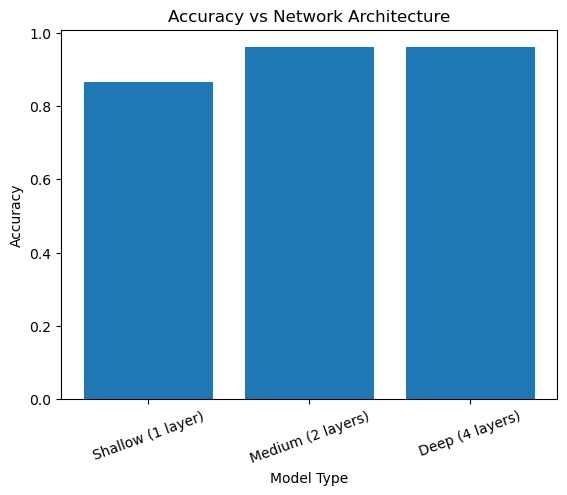

In [6]:
plt.figure()
plt.bar(results.keys(), results.values())
plt.title("Accuracy vs Network Architecture")
plt.xlabel("Model Type")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

In [7]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.title(title)
    plt.show()

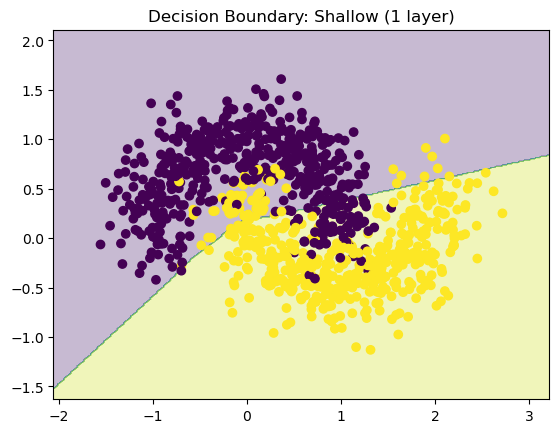

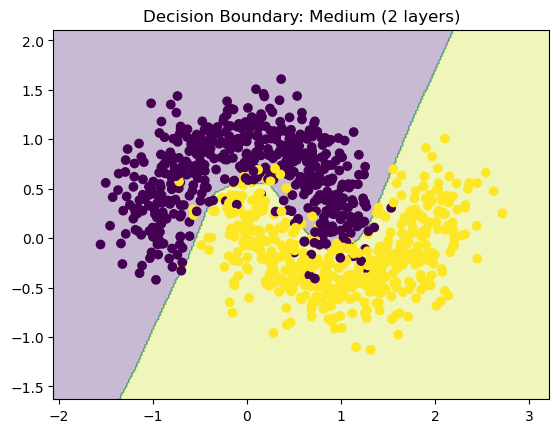

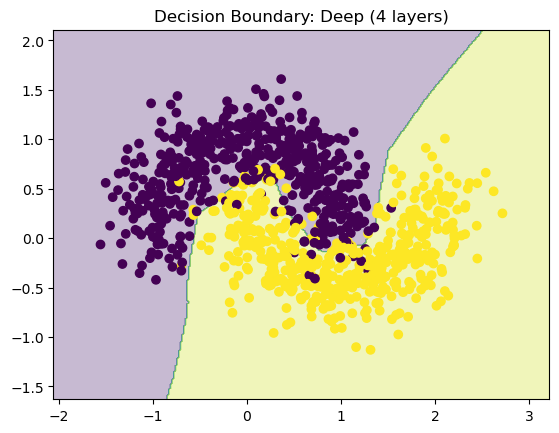

In [8]:
for name, model in trained_models.items():
    plot_decision_boundary(model, X, y, f"Decision Boundary: {name}")

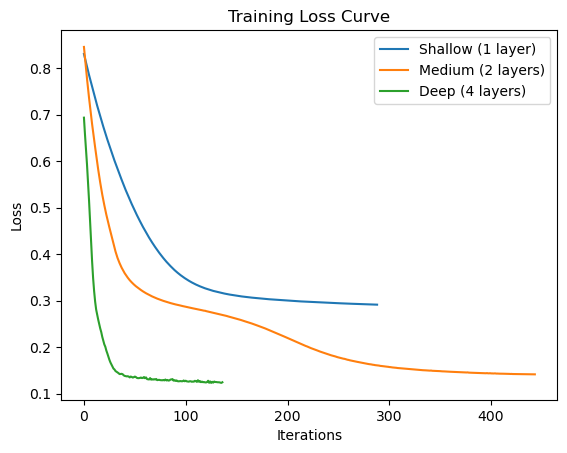

In [9]:
plt.figure()

for name, model in trained_models.items():
    plt.plot(model.loss_curve_, label=name)

plt.title("Training Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()